<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
!pip install pmdarima

In [108]:
!pip install arch

In [109]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error
from arch import arch_model
from sklearn.metrics import mean_absolute_percentage_error

#Grupo México

In [110]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')

/tmp/ipykernel_3088/382611023.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01', end ='2026-06-26')
[*********************100%***********************]  1 of 1 completed


In [111]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [112]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [113]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

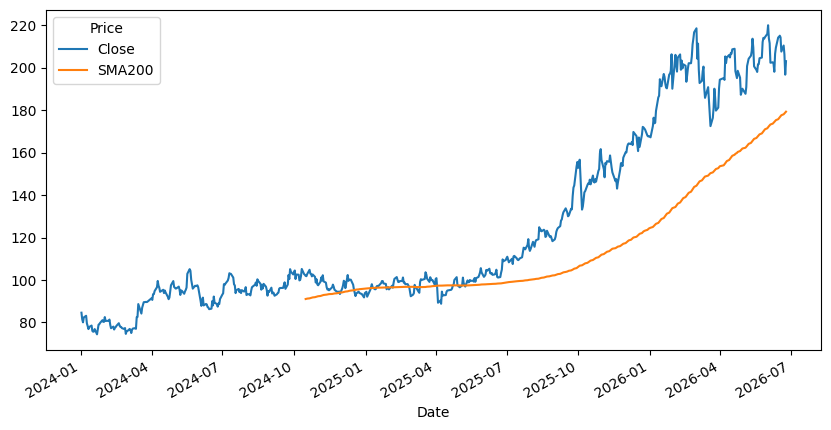

In [114]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [115]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [116]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

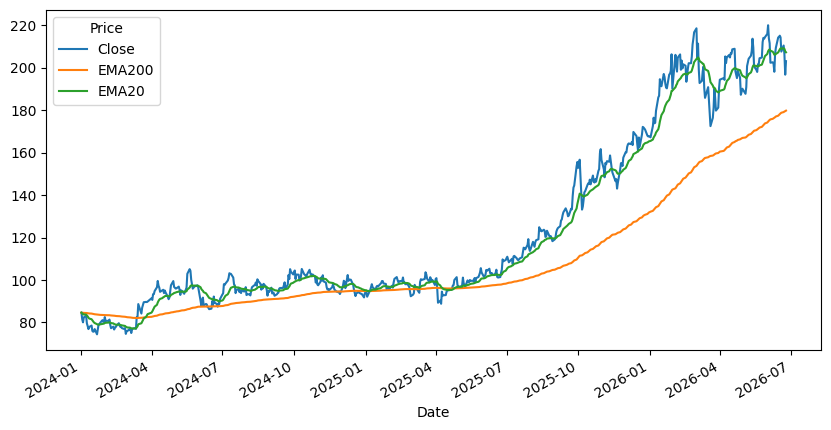

In [117]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

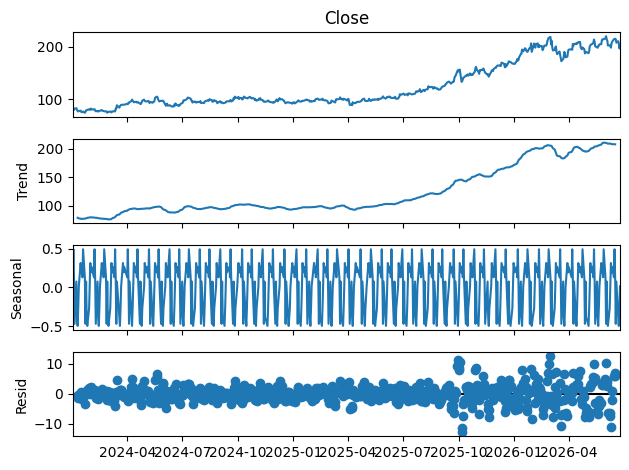

In [118]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

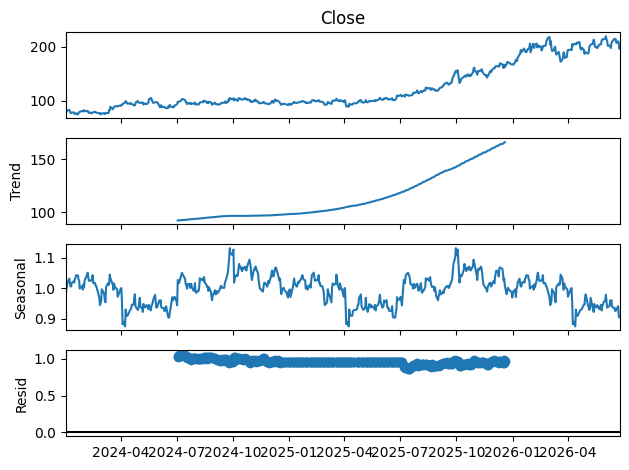

In [119]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

#Volatilidad

##Desviación Estándar

In [120]:
#Obtener datos
precios = df['Close']

In [121]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 621, dtype: float64


In [122]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 620, dtype: float64


In [123]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()
print(f"Volatilidad diaria: {volatilidad_diaria:.4f}")

Volatilidad diaria: 0.0223


In [124]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)
print(f"Volatilidad anualizada: {volatilidad_anual:.4f}")

Volatilidad anualizada: 0.3543


In [125]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [126]:
print(f"Volatilidad diaria: {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 2.2316 %
Volatilidad anualizada: 35.4254 %


##Average True Range

In [127]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [128]:
print(high_low)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-19     8.240005
2026-06-22     7.779999
2026-06-23     9.880005
2026-06-24    10.000000
2026-06-25     8.190002
Length: 620, dtype: float64


In [129]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117682
2024-01-05    6.046948
2024-01-08    0.887134
2024-01-09    0.253468
                ...   
2026-06-19    0.399994
2026-06-22    3.880005
2026-06-23    1.550003
2026-06-24    1.100006
2026-06-25    8.050003
Length: 620, dtype: float64


In [130]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525594
2024-01-05     0.334934
2024-01-08     1.683729
2024-01-09     3.946808
                ...    
2026-06-19     7.840012
2026-06-22     3.899994
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     0.139999
Length: 620, dtype: float64


In [131]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [132]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-06-19     8.240005
2026-06-22     7.779999
2026-06-23    11.430008
2026-06-24    11.100006
2026-06-25     8.190002
Length: 620, dtype: float64


In [133]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [134]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [135]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-19  214.610001  206.369995  207.500000       7.544827
2026-06-22  211.380005  203.600006  210.360001       7.561625
2026-06-23  208.809998  198.929993  206.100006       7.837938
2026-06-24  205.000000  195.000000  196.639999       8.070943
2026-06-25  204.690002  196.500000  202.990005       8.079447


In [136]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: ${atr_diario:.4f}")

ATR diario: $4.2903


In [137]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: ${atr_anualizado:.4f}")

ATR anualizado: $68.1064


In [138]:
# Obtener el último precio de cierre (el del 26/06/26)
precio_cierre_final = df['Close'].iloc[-1]
print("El último precio de cierre es: $", precio_cierre_final)

El último precio de cierre es: $ 202.99000549316406


In [139]:
#Convertimos en porcentaje ya que lo anterior es calculado con precios de cierre
ATR_diario_porcentaje = (atr_diario/precio_cierre_final) * 100
ATR_anualizado_porcentaje = (atr_anualizado/precio_cierre_final) * 100

In [140]:
print(f"ATR diario: {ATR_diario_porcentaje:.4f} %")
print(f"ATR anualizado: {ATR_anualizado_porcentaje:.4f} %")

ATR diario: 2.1136 %
ATR anualizado: 33.5516 %


#Parámetros (p,d,q)

##Estacionariedad

###Prueba Dickey Fuller

In [141]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [142]:
#Obtener datos precios de cierre originales
precios = df['Close']

In [143]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.2948
Valor p: 0.9771
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9771046796736259)

In [144]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada) a los rendimientos logarítmicos
probar_estacionariedad(df['Rendimientos_Log'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -27.1185
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

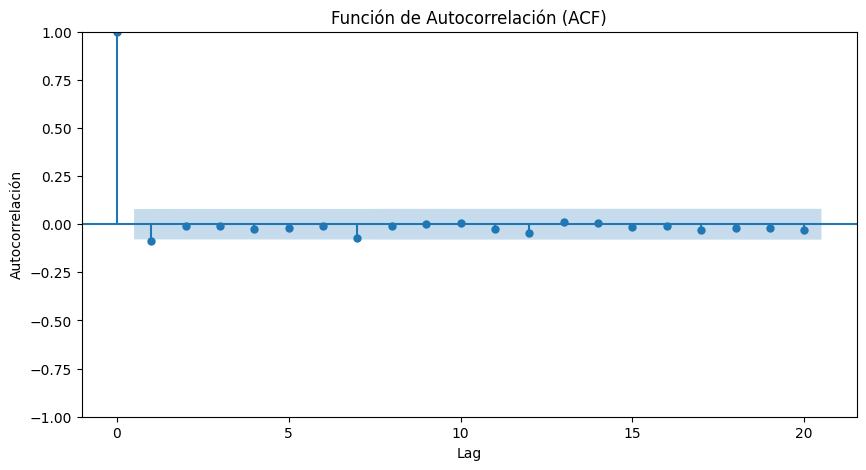

In [145]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

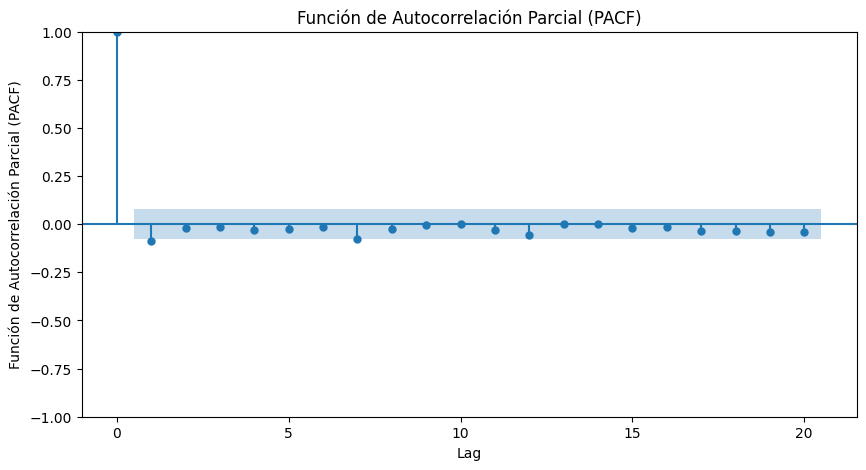

In [146]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['Rendimientos_Log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#Monte Carlo

In [147]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-19   -0.031826
2026-06-22    0.013689
2026-06-23   -0.020459
2026-06-24   -0.046987
2026-06-25    0.031782
Name: Rendimientos_Log, Length: 620, dtype: float64


In [148]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -27.1185
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [149]:
media_retornos = retornos.mean()
print(f"La media de los retornos es: {media_retornos:.6f}")

La media de los retornos es: 0.001411


In [150]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(f"La desviación de los retornos es: {desviacion_retornos:.6f}")

La desviación de los retornos es: 0.022316


In [151]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [152]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print("El último precio de cierre es: $", ultimo_precio_cierre)

El último precio de cierre es: $ 202.99000549316406


In [153]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [154]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

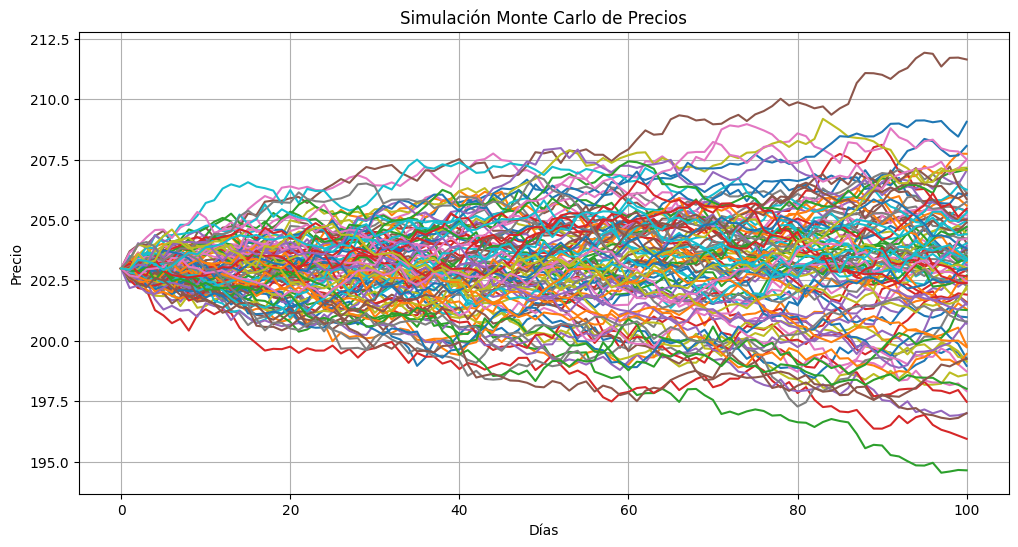

In [155]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [156]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [157]:
# Se extrae la última columna de los precios simulados
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      202.990005
1      202.939498
2      203.339966
3      203.300485
4      203.170577
          ...    
96     203.589178
97     203.330668
98     203.660928
99     203.513829
100    203.311985
Name: 99, Length: 101, dtype: float64


In [158]:
#Precio de cierre número 100
precio_cien = df['Close'][-101]
print(f"El precio de cierre número cien es: $ {precio_cien: .2f}")

El precio de cierre número cien es: $  198.46


/tmp/ipykernel_3088/3328606284.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][-101]


In [159]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [160]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

        0         1         2        3         4         5         6    \
0  4.527481  4.476974  4.877442  4.83796  4.708052  4.462105  4.624807   

       7         8         9    ...       91        92        93        94   \
0  4.91344  5.191668  5.111833  ...  4.668953  4.383332  4.928951  5.098398   

        95        96        97        98        99       100  
0  4.944114  5.126653  4.868144  5.198403  5.051304  4.84946  

[1 rows x 101 columns]


In [161]:
#Contar %Ganancias y %Pérdidas si el precio de compra es lo que vale el precio de cierre número cien
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [162]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(f"Ganancia Potencial: $ {Ganancia_potencial: .2f}")

Ganancia Potencial: $  5.60


In [163]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(f"Precio Potencial: $ {Precio_potencial: .2f}")

Precio Potencial: $  204.06


##Error Cuadrático Medio (RMSE)


In [187]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [188]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [189]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-26    196.718246
2026-01-27    197.053329
2026-01-28    198.462524
2026-01-29    206.218124
2026-01-30    190.026962
                 ...    
2026-06-17    214.979996
2026-06-18    214.210007
2026-06-19    207.500000
2026-06-22    210.360001
2026-06-23    206.100006
Name: Close, Length: 101, dtype: float64


In [190]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [191]:
rmse = math.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 10.0837


In [192]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 5.0195 %


##Error Cuadrático Medio (MAE)

In [193]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 7.7933


In [194]:
mae_porcentaje = (mae / ultimos_101.mean()) * 100
print(f"% MAE Monte Carlo: {mae_porcentaje:.4f} %")

% MAE Monte Carlo: 3.8794 %


##Error Porcentual Absoluto Medio (MAPE)

In [184]:
# Using scikit-learn
mape = mean_absolute_percentage_error(ultimos_101, prediccion_mc) * 100
print(f"MAPE: {mape:.4f}%")

MAPE: 3.9780%
